In [2]:
%pip install tensorflow keras

import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from PIL import Image
from sklearn.model_selection import train_test_split
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from keras.optimizers import Adam
from sklearn.metrics import accuracy_score
np.random.seed(42)

from matplotlib import style
style.use('fivethirtyeight')

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 1. Asssigning Path from Dataset

In [5]:
data_dir = r"C:\Users\debru\OneDrive - SemiFive\ADAS_Project\raspberry_pi\traffic_sign_cnn\W2_traffic_sign_cnn"
train_path = 'Train'
test_path = 'Test'

# Resizing the images to a fixed size (30x30x3)
IMG_HIGHT = 30
IMG_WIDTH = 30
channels = 3

### 2. Finding Total Classes

In [7]:
# Resolve the correct dataset root if current data_dir does not contain Train/
train_dir = os.path.join(data_dir, train_path)

if not os.path.isdir(train_dir):
	candidate_roots = [
		data_dir,
		os.path.join(data_dir, "traffic_sign_cnn"),
		os.path.dirname(data_dir),
	]

	resolved_root = None
	for root in candidate_roots:
		if os.path.isdir(os.path.join(root, train_path)):
			resolved_root = root
			break

	if resolved_root is None:
		# Fallback: search recursively for a folder that contains Train/
		for root, dirs, _ in os.walk(data_dir):
			if train_path in dirs:
				resolved_root = root
				break

	if resolved_root is None:
		raise FileNotFoundError(
			f"Could not find '{train_path}' under data_dir='{data_dir}'. "
			"Please set data_dir to the folder that contains Train and Test."
		)

	data_dir = resolved_root
	train_dir = os.path.join(data_dir, train_path)

NUM_CATEGORIES = len([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
print("Using data_dir:", data_dir)
print("Number of categories:", NUM_CATEGORIES)

Using data_dir: C:\Users\debru\OneDrive - SemiFive\ADAS_Project\raspberry_pi\traffic_sign_cnn\W2_traffic_sign_cnn
Number of categories: 43


### 3. Visualizing The Dataset

Categories:  ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '5', '6', '7', '8', '9']


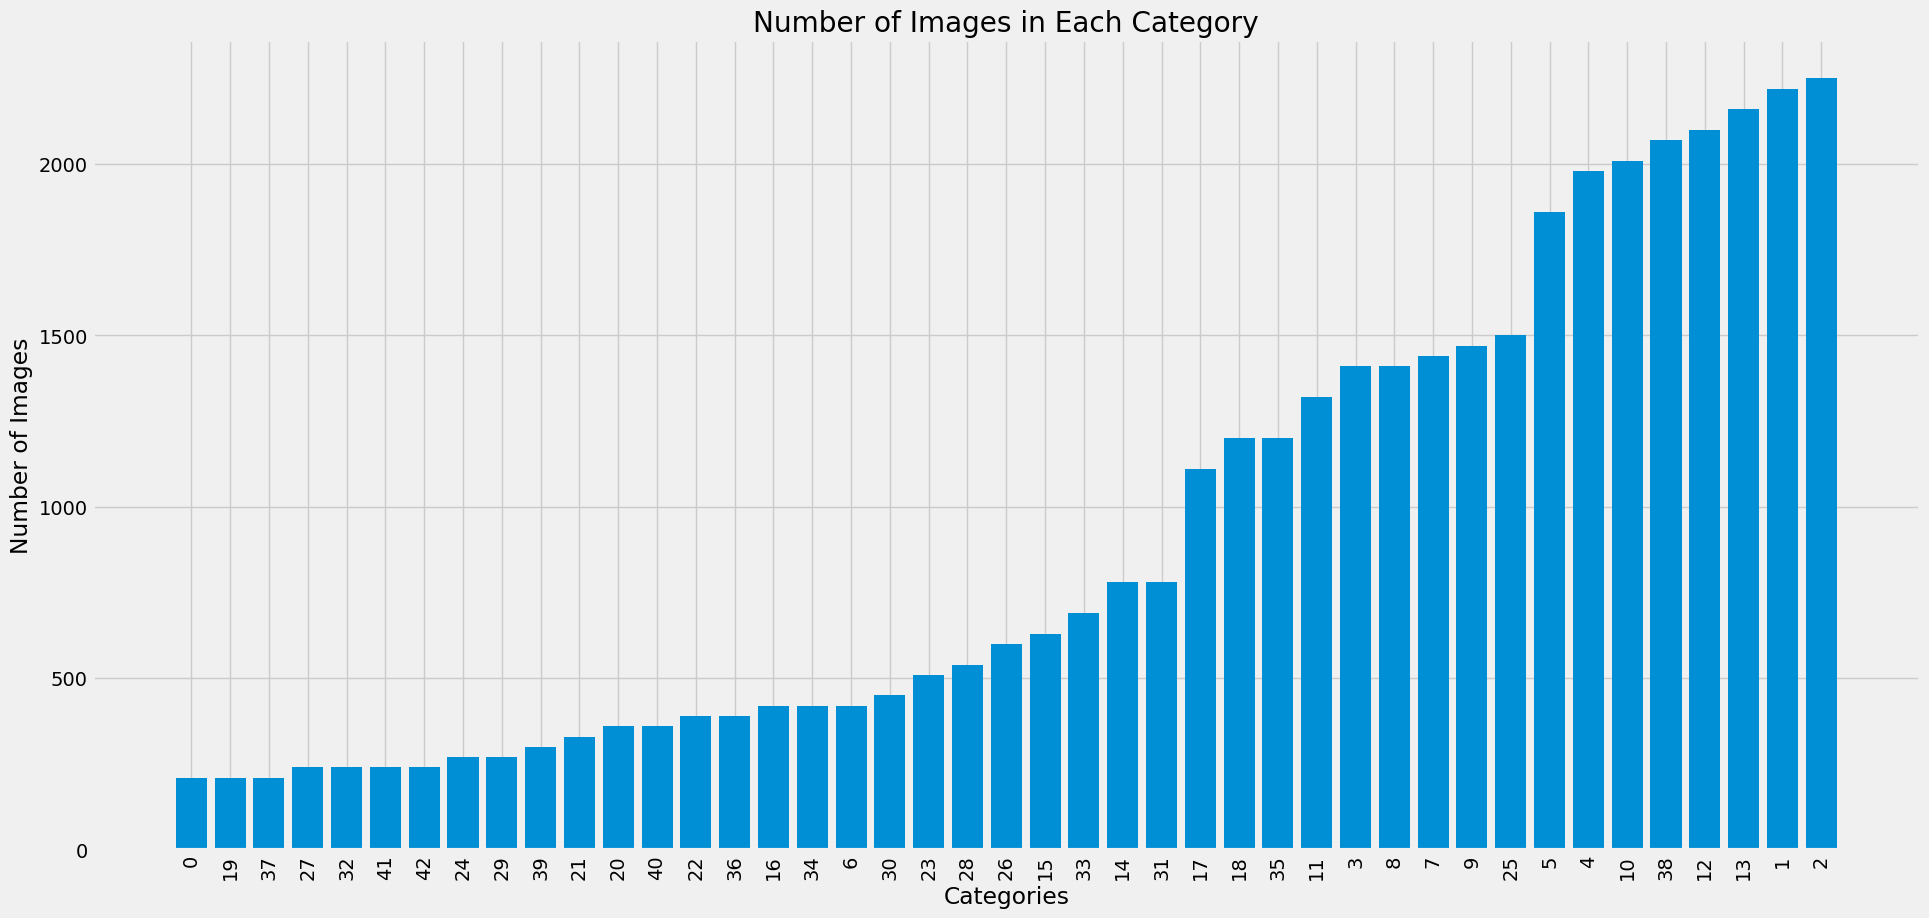

In [8]:
forders = os.listdir(os.path.join(data_dir, train_path))
print("Categories: ", forders)

train_number = []
class_number = []

for folder in forders:
    path = os.path.join(data_dir, train_path, folder)
    num_of_images = len(os.listdir(path))
    train_number.append(num_of_images)
    class_number.append(folder)

# Sort the data based on the number of images in each category
zipped_lists = zip(train_number, class_number)
sorted_pairs = sorted(zipped_lists)
tuples = zip(*sorted_pairs)
train_number, class_number = [list(tuple) for tuple in tuples]

# Plotting the number of images in each category
plt.figure(figsize=(21, 10))
plt.bar(class_number, train_number)
plt.xlabel('Categories')
plt.ylabel('Number of Images')
plt.title('Number of Images in Each Category')
plt.xticks(rotation=90)
plt.show()

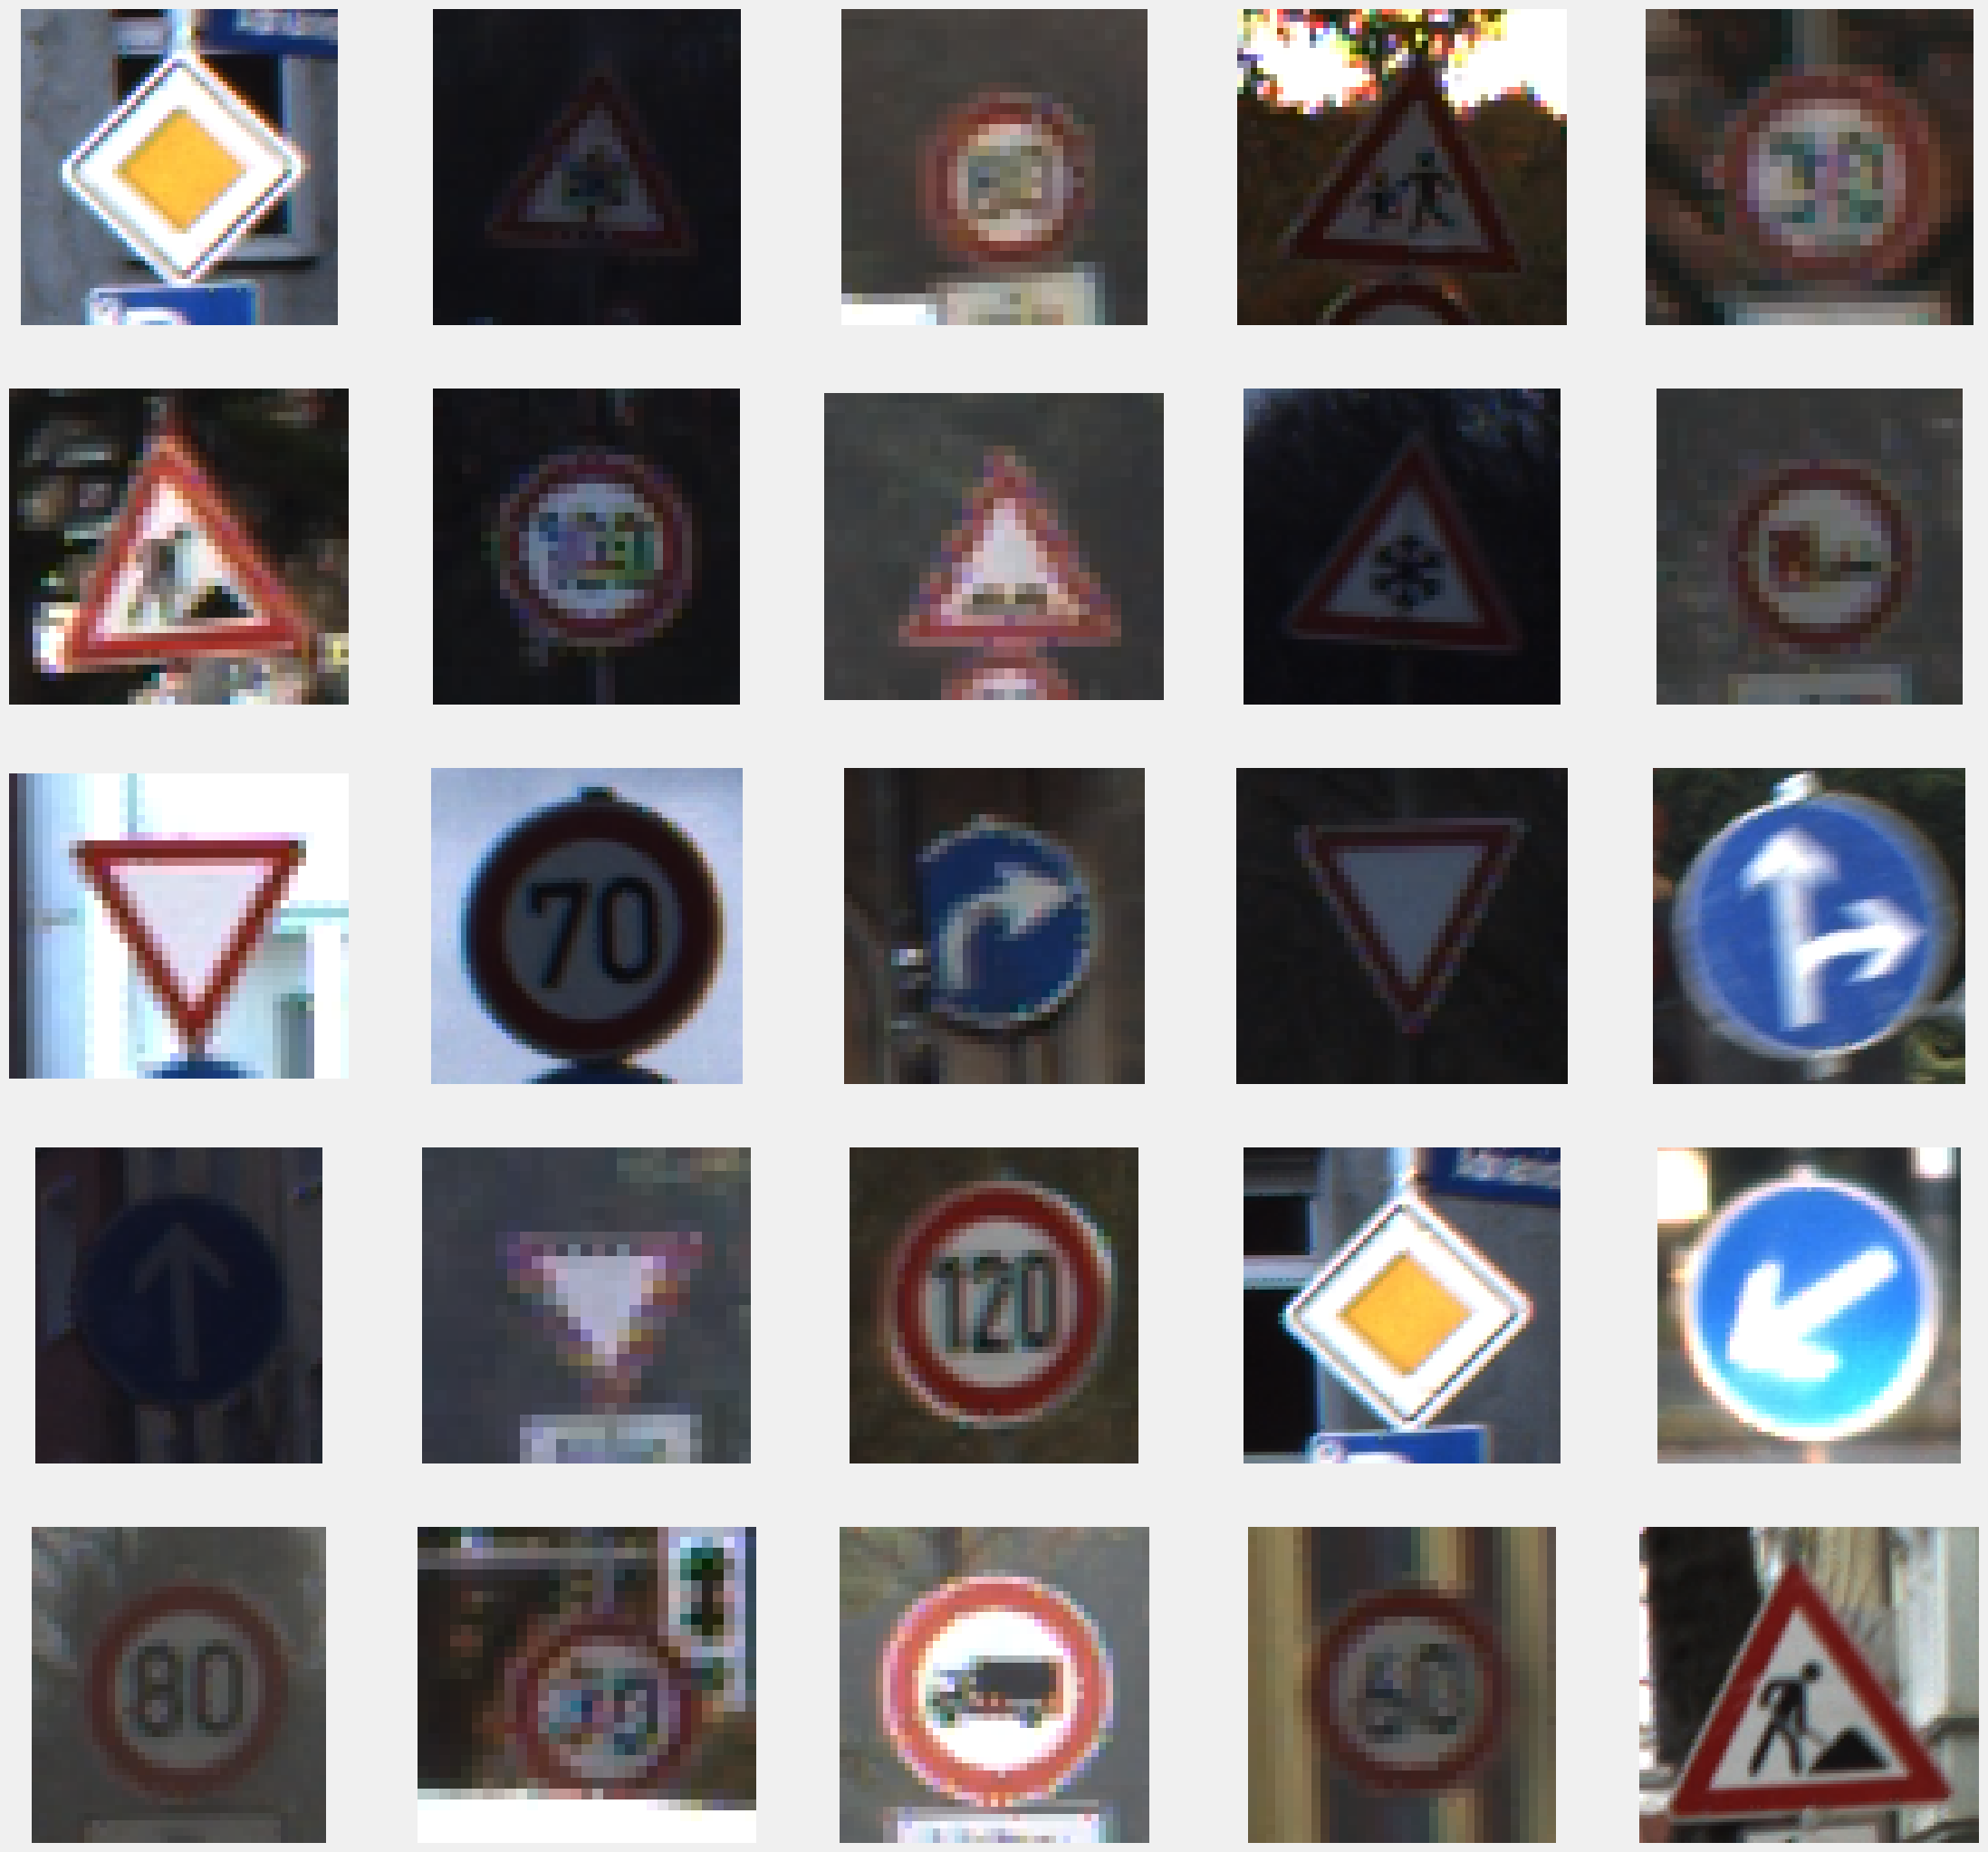

In [11]:
#Visualizing 25 random images from the dataset
import random

test =pd.read_csv(os.path.join(data_dir, 'Test.csv'))
imgs = test['Path'].values

plt.figure(figsize=(25, 25))

for i in range(25):
    random_index = random.randint(0, len(imgs) - 1)
    img_path = os.path.join(data_dir, imgs[random_index])
    img = plt.imread(img_path)
    plt.subplot(5, 5, i + 1)
    plt.imshow(img)
    plt.axis('off')
plt.show()

### 4. Collecting the Training Data

In [12]:
image_data = []
image_labels = []

for i in range(NUM_CATEGORIES):
    path = os.path.join(data_dir, train_path, str(i))
    class_num = i
    for img in os.listdir(path):
        try:
            img_array = cv2.imread(os.path.join(path, img))
            img_array = cv2.resize(img_array, (IMG_WIDTH, IMG_HIGHT))
            image_data.append(img_array)
            image_labels.append(class_num)
        except Exception as e:
            print(e)

# Changing the list to numpy array
image_data = np.array(image_data)
image_labels = np.array(image_labels)

print("Image data shape: ", image_data.shape)
print("Image labels shape: ", image_labels.shape)

Image data shape:  (39209, 30, 30, 3)
Image labels shape:  (39209,)


### 5. Shuffling the Training Data

In [13]:
shuffle_indexes = np.arange(image_data.shape[0])
np.random.shuffle(shuffle_indexes)
image_data = image_data[shuffle_indexes]
image_labels = image_labels[shuffle_indexes]

### 6. Splitting the data into train and validation set

In [14]:
# Splitting the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(image_data, image_labels, test_size=0.3, random_state=42, shuffle=True)
X_train = X_train / 255.0
X_val = X_val / 255.0

print("Training data shape: ", X_train.shape)
print("Validation data shape: ", X_val.shape)
print("Training labels shape: ", y_train.shape)
print("Validation labels shape: ", y_val.shape)

Training data shape:  (27446, 30, 30, 3)
Validation data shape:  (11763, 30, 30, 3)
Training labels shape:  (27446,)
Validation labels shape:  (11763,)


### 7. One hot encoding the labels

In [15]:
y_train = keras.utils.to_categorical(y_train, NUM_CATEGORIES)
y_val = keras.utils.to_categorical(y_val, NUM_CATEGORIES)

print("Training labels shape after one-hot encoding: ", y_train.shape)
print("Validation labels shape after one-hot encoding: ", y_val.shape)

Training labels shape after one-hot encoding:  (27446, 43)
Validation labels shape after one-hot encoding:  (11763, 43)


### 8. Make the model CNN

In [18]:
model = Sequential([
    Conv2D(filters=16, kernel_size=(3, 3), activation='relu', input_shape=(IMG_HIGHT, IMG_WIDTH, channels)),
    Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    BatchNormalization(axis=-1),

    Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    Conv2D(filters=128, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    BatchNormalization(axis=-1),

    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(NUM_CATEGORIES, activation='softmax')
])

c:\Users\debru\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
lr = 0.001
epochs = 30

opt = Adam(learning_rate=lr)
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])


### 9. Augmenting the Data and Training the model

In [22]:
aug = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=False,
    vertical_flip=False,
    fill_mode="nearest")
history = model.fit(aug.flow(X_train, y_train, batch_size=32), validation_data=(X_val, y_val), epochs=epochs)

Epoch 1/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.6875 - loss: 1.1447 - val_accuracy: 0.9692 - val_loss: 0.1081
Epoch 2/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.9353 - loss: 0.2121 - val_accuracy: 0.9668 - val_loss: 0.1075
Epoch 3/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.9577 - loss: 0.1369 - val_accuracy: 0.9737 - val_loss: 0.0901
Epoch 4/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.9664 - loss: 0.1034 - val_accuracy: 0.9906 - val_loss: 0.0317
Epoch 5/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.9712 - loss: 0.0928 - val_accuracy: 0.9781 - val_loss: 0.0686
Epoch 6/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.9765 - loss: 0.0769 - val_accuracy: 0.9930 - val_loss: 0.0192
Epoch 7/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.9772 - loss: 0.0748 - val_accuracy: 0.9958 - val_loss: 0.0123
Epoch 8/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.9832 - loss: 0.0549 - 

In [23]:
model.save('traffic_sign_model.h5')

In [ ]:
###??? model.save_weights('traffic_sign_model_weights.h5') 

In [24]:
dir(aug)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_api_export_path',
 '_api_export_symbol_id',
 '_validation_split',
 'apply_transform',
 'brightness_range',
 'channel_axis',
 'channel_shift_range',
 'col_axis',
 'cval',
 'data_format',
 'dtype',
 'featurewise_center',
 'featurewise_std_normalization',
 'fill_mode',
 'fit',
 'flow',
 'flow_from_dataframe',
 'flow_from_directory',
 'get_random_transform',
 'height_shift_range',
 'horizontal_flip',
 'interpolation_order',
 'mean',
 'preprocessing_function',
 'random_transform',
 'rescale',
 'rotation_range',
 'row_axis',
 'samplewise_center',
 'samplewise_std_normalization',
 'shear_range',
 'standardize'

### 10. Evaluating the model

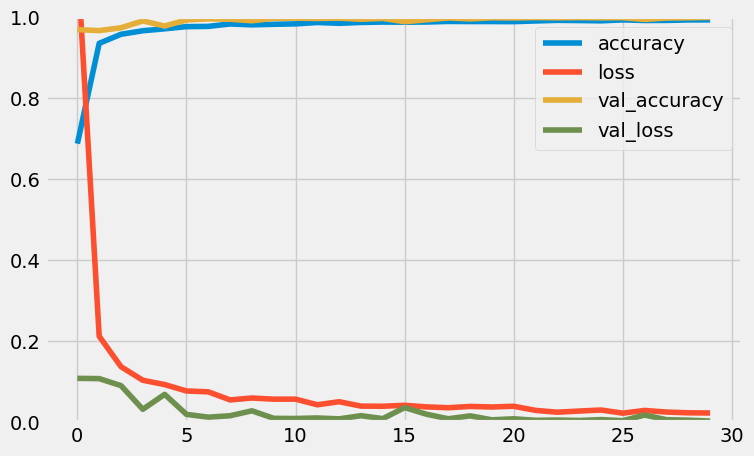

In [25]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

### 11. Loading the test data and running th predictions

In [28]:
test =pd.read_csv(os.path.join(data_dir, 'Test.csv'))
labels = test['ClassId'].values
imgs = test['Path'].values

data = []

for img in imgs:
    try:
        img_array = cv2.imread(os.path.join(data_dir, img))
        image_fromarray = Image.fromarray(img_array, 'RGB')
        resize_image = image_fromarray.resize((IMG_WIDTH, IMG_HIGHT))
        data.append(np.array(resize_image))
    except Exception as e:
        print(e)

X_test = np.array(data)
X_test = X_test / 255.0

pred_probs = model.predict(X_test)
predictions = np.argmax(pred_probs, axis=1)

# Accuracy on the test set
accuracy = accuracy_score(labels, predictions) * 100
print("Test set accuracy: {:.2f}%".format(accuracy))

C:\Users\debru\AppData\Local\Temp\ipykernel_8048\2593612144.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image_fromarray = Image.fromarray(img_array, 'RGB')


395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
Test set accuracy: 98.81%


### 12. Visulizing the Confusion matrix

In [29]:
from sklearn.metrics import confusion_matrix
cf = confusion_matrix(labels, predictions)
print("Confusion Matrix:\n", cf)

Confusion Matrix:
 [[ 60   0   0 ...   0   0   0]
 [  0 720   0 ...   0   0   0]
 [  0   1 749 ...   0   0   0]
 ...
 [  0   0   0 ...  87   0   0]
 [  0   0   0 ...   0  60   0]
 [  0   0   0 ...   0   4  86]]



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


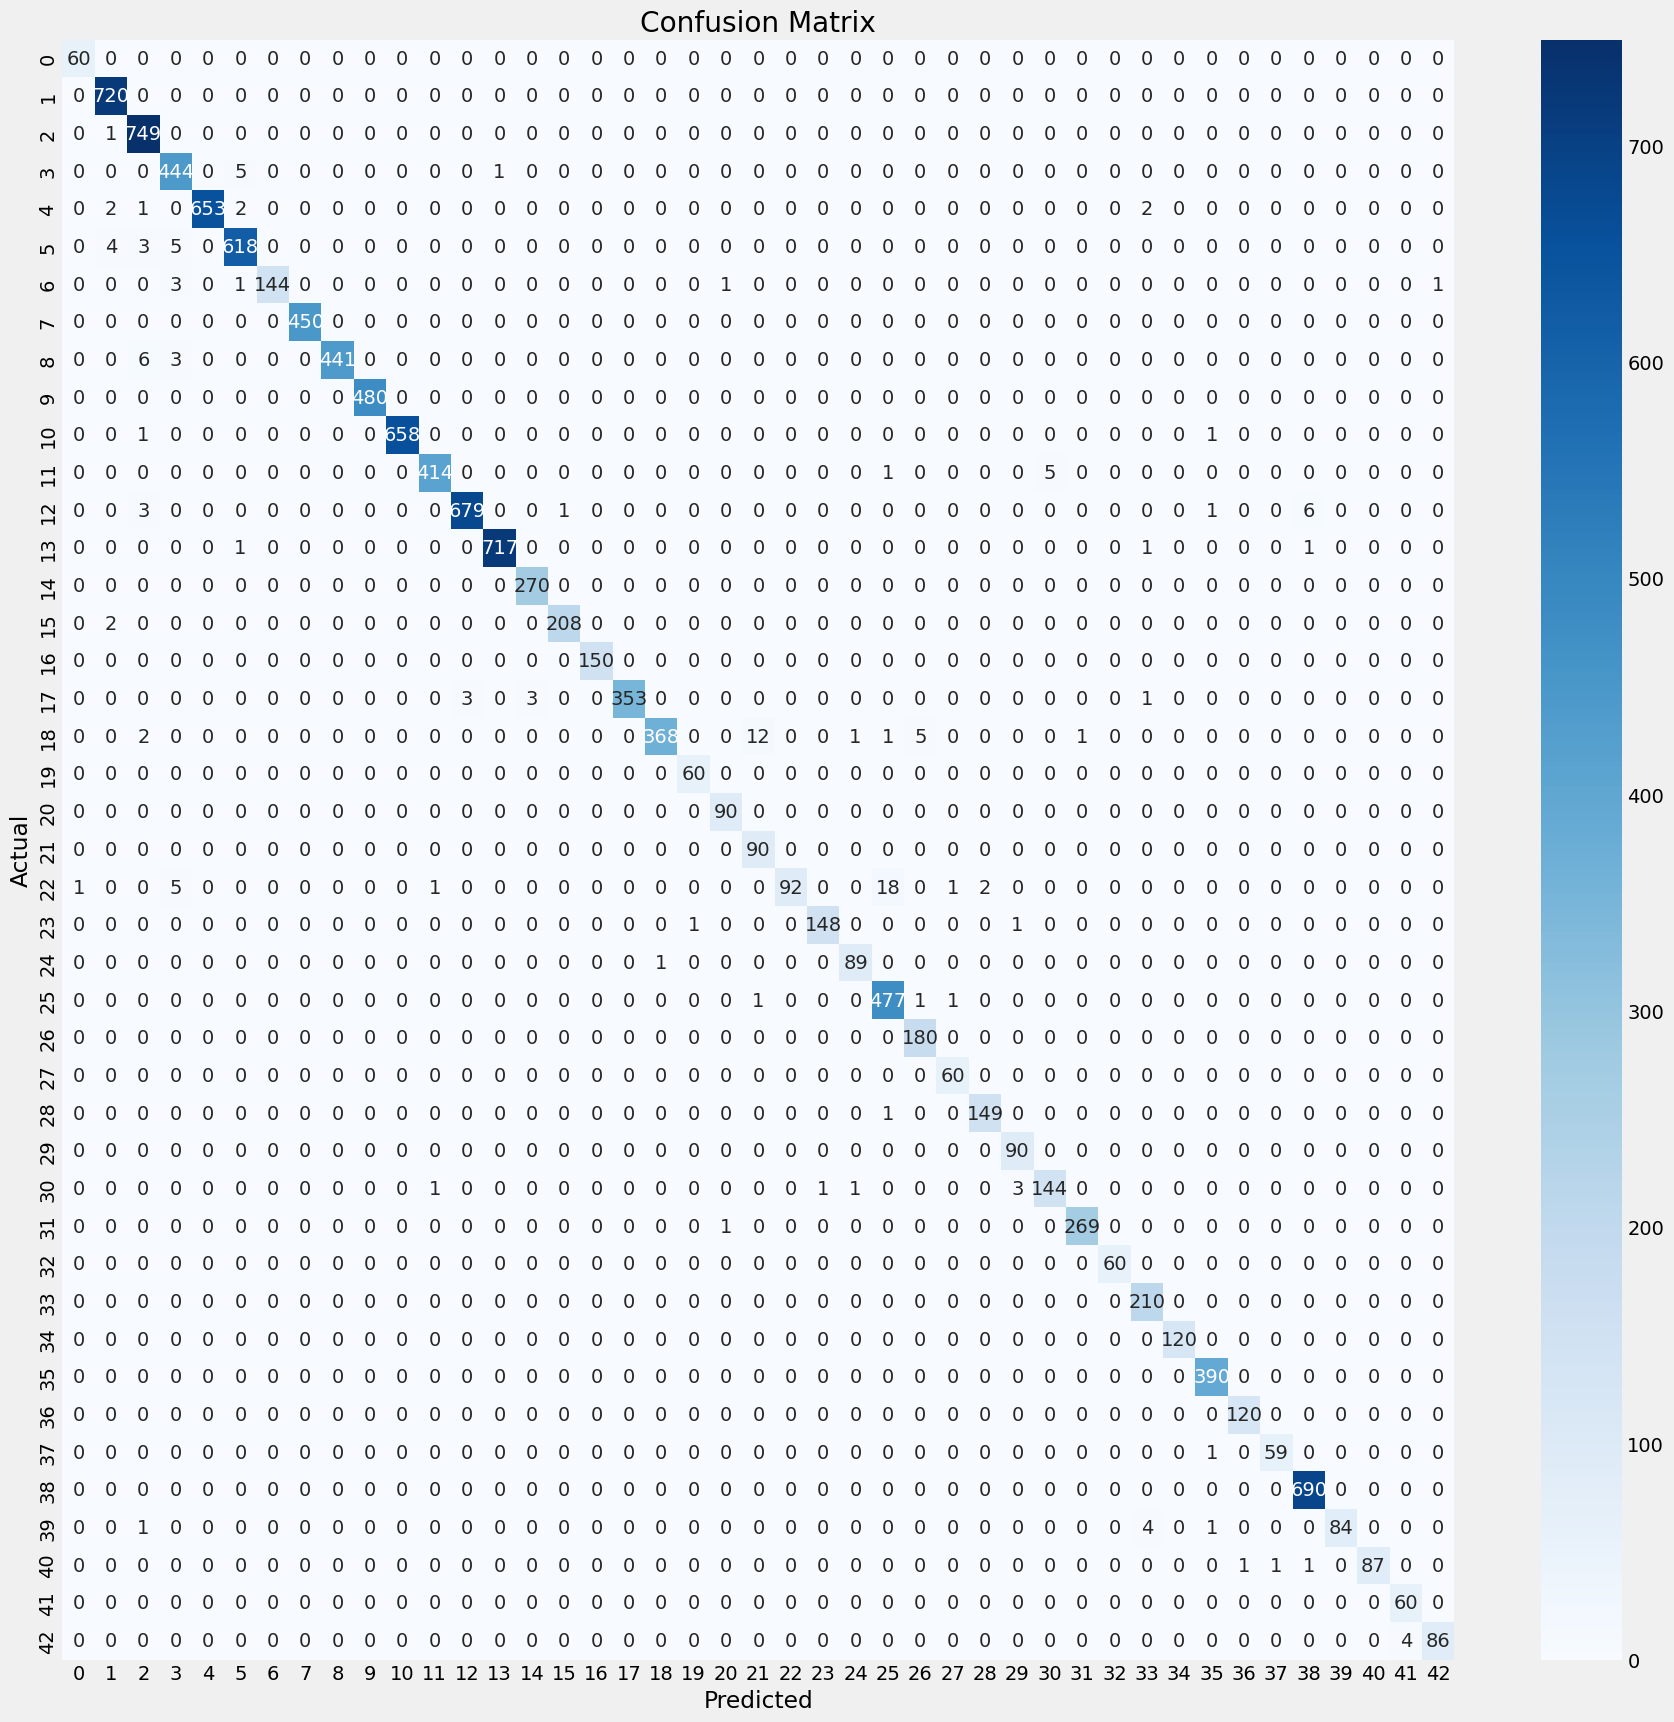

In [33]:
%pip install seaborn

import seaborn as sns
df_cm = pd.DataFrame(cf, index=range(NUM_CATEGORIES), columns=range(NUM_CATEGORIES))
plt.figure(figsize=(20, 20))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Classification report

In [34]:
from sklearn.metrics import classification_report
print("Classification Report:\n", classification_report(labels, predictions))

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99        60
           1       0.99      1.00      0.99       720
           2       0.98      1.00      0.99       750
           3       0.97      0.99      0.98       450
           4       1.00      0.99      0.99       660
           5       0.99      0.98      0.98       630
           6       1.00      0.96      0.98       150
           7       1.00      1.00      1.00       450
           8       1.00      0.98      0.99       450
           9       1.00      1.00      1.00       480
          10       1.00      1.00      1.00       660
          11       1.00      0.99      0.99       420
          12       1.00      0.98      0.99       690
          13       1.00      1.00      1.00       720
          14       0.99      1.00      0.99       270
          15       1.00      0.99      0.99       210
          16       1.00      1.00      1.00       150
   

#### 14. Prediction on Test Data

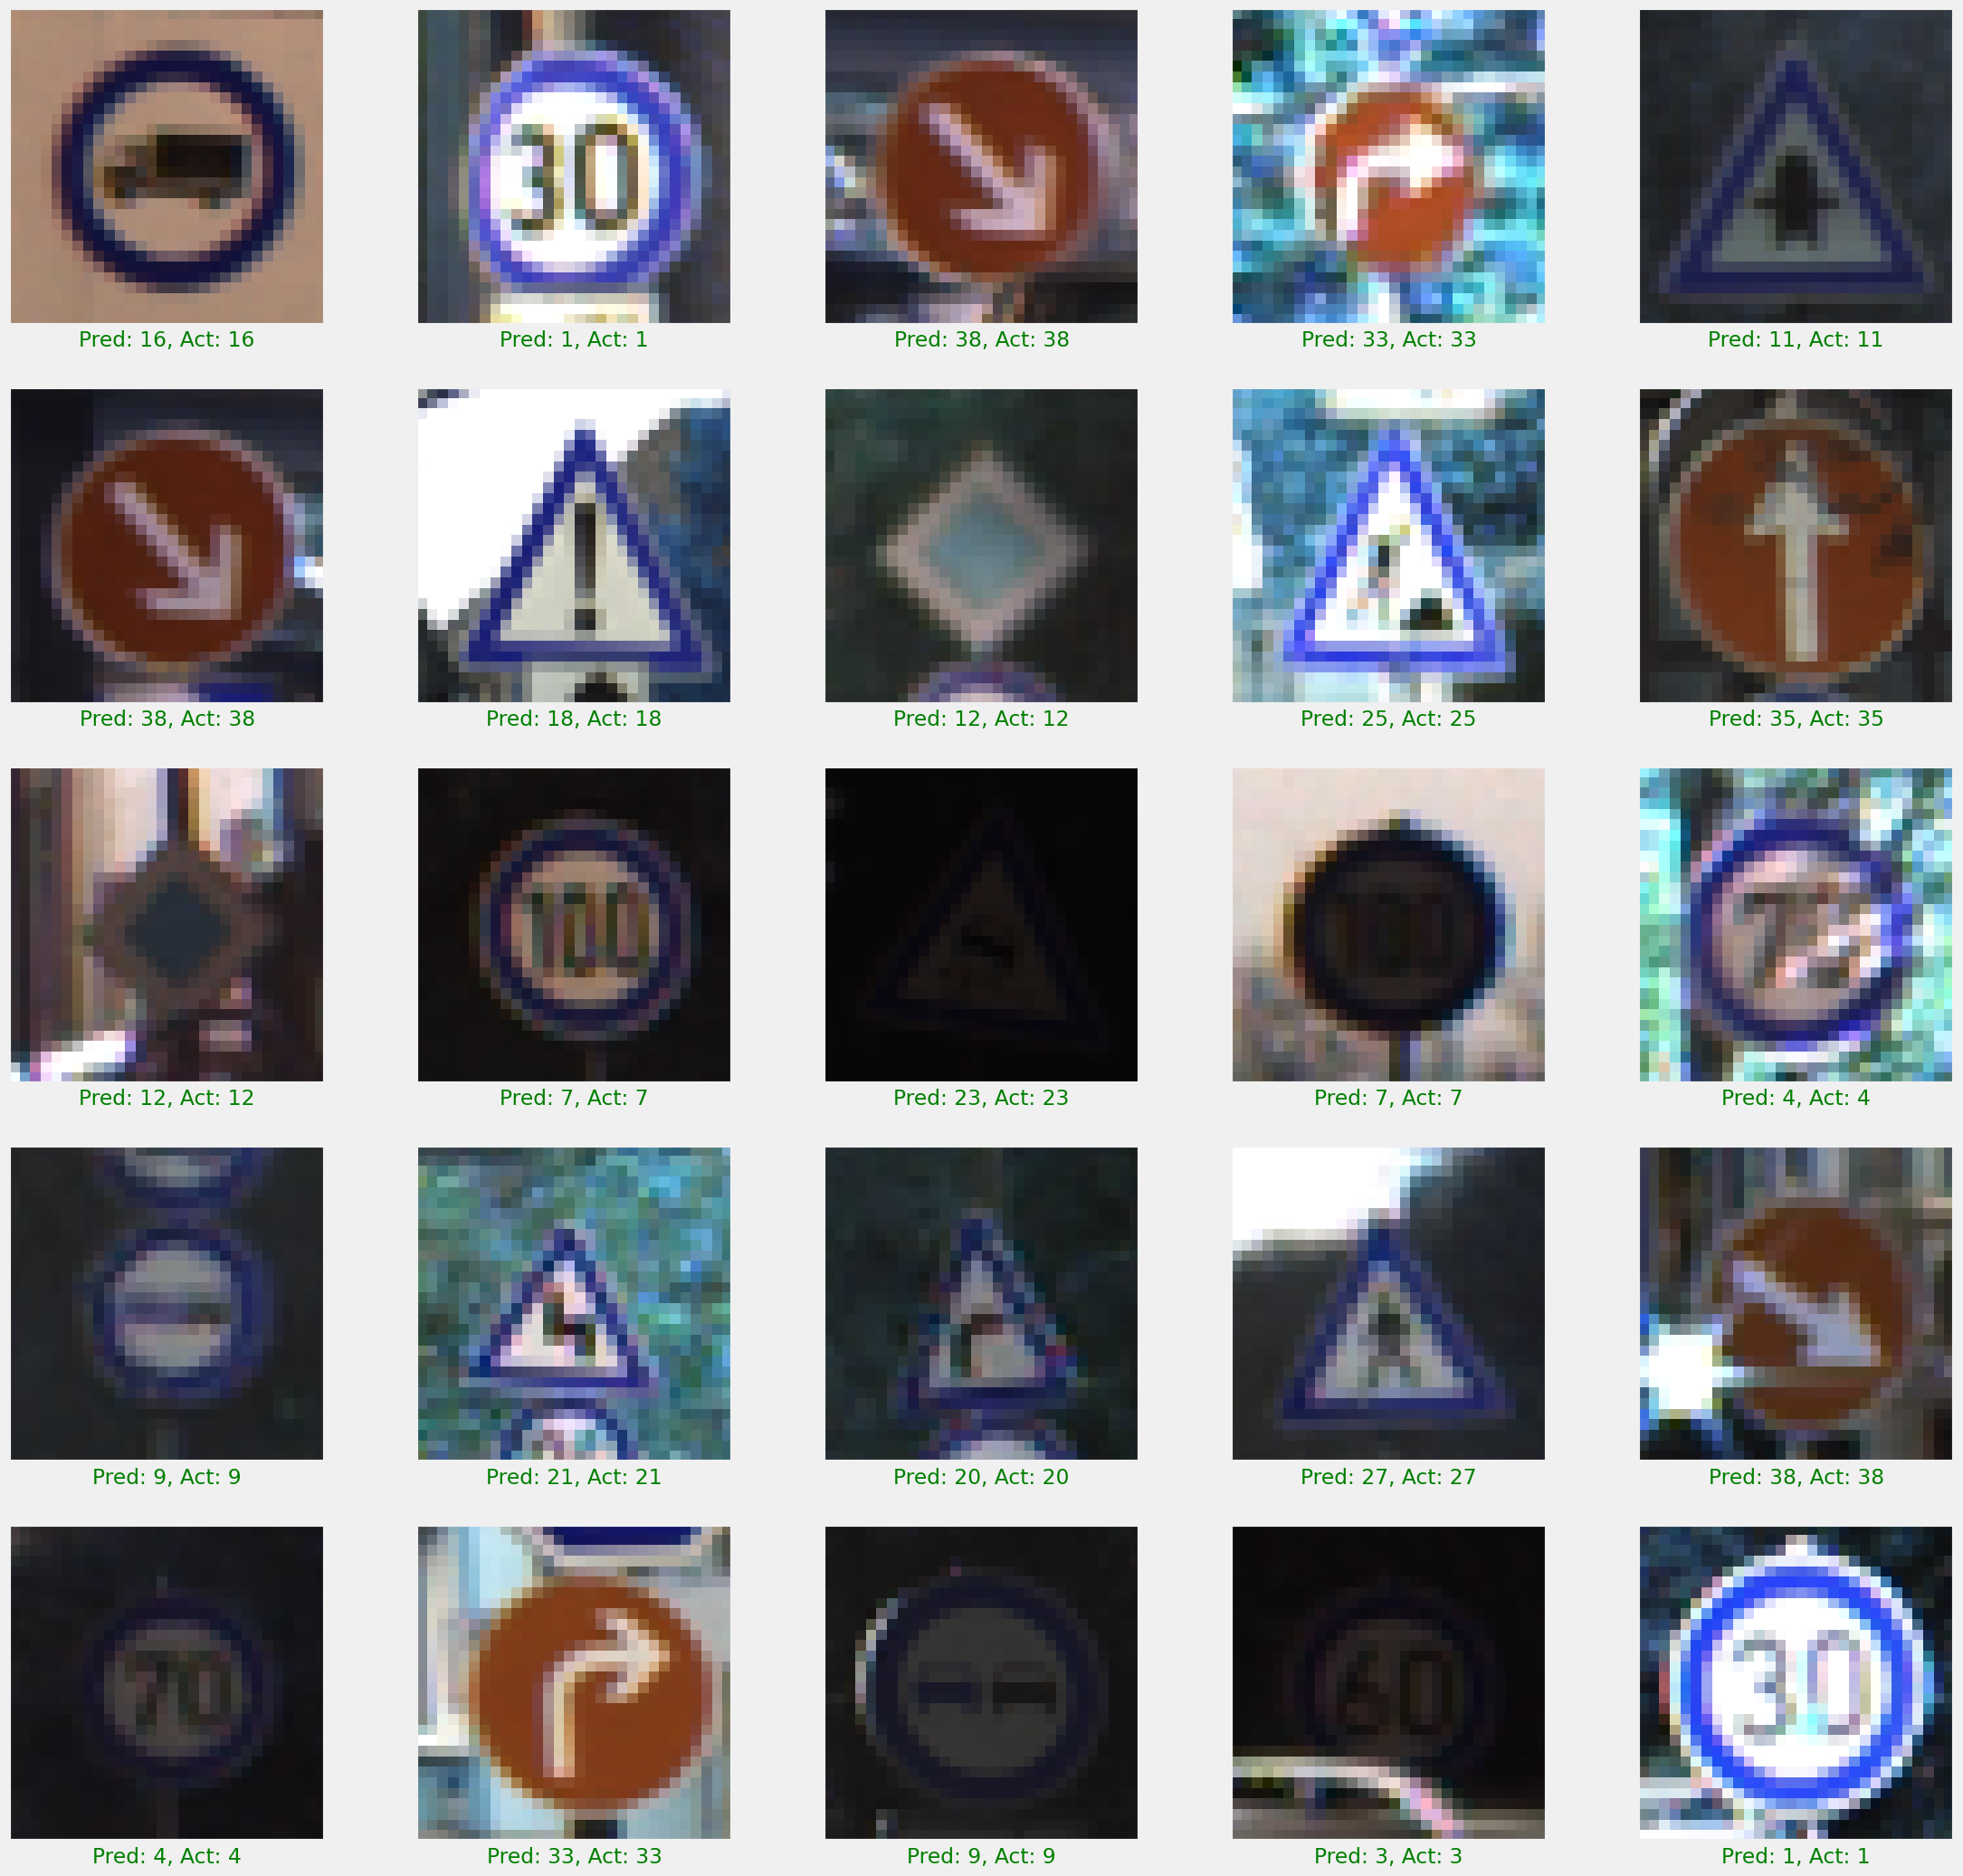

In [35]:
plt.figure(figsize=(25, 25))

start_index = 0
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    prediction = predictions[start_index + i]
    actual = labels[start_index + i]
    col = 'g'
    if prediction != actual:
        col = 'r'  
    plt.xlabel(f"Pred: {prediction}, Act: {actual}", color=col)
    plt.imshow(X_test[start_index + i])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


C:\Users\debru\AppData\Local\Temp\ipykernel_8048\2503688996.py:8: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image_fromarray = Image.fromarray(image, 'RGB')


Predicted class:  1


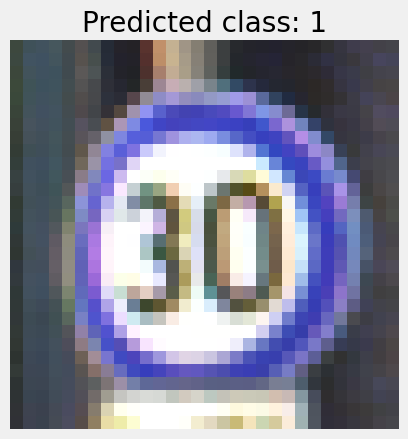

In [37]:
model_path = 'traffic_sign_model.h5'
loaded_model = keras.models.load_model(model_path)

import matplotlib.pyplot as plt
import numpy as np

image = cv2.imread(os.path.join(data_dir, 'Test', '00001.png'))
image_fromarray = Image.fromarray(image, 'RGB')
resize_image = image_fromarray.resize((IMG_WIDTH, IMG_HIGHT))
expand_input = np.expand_dims(resize_image, axis=0)
input_data = np.array(expand_input)
input_data = input_data / 255.0

prediction = loaded_model.predict(input_data)
result = np.argmax(prediction)
print("Predicted class: ", result)
plt.imshow(resize_image)
plt.title(f"Predicted class: {result}")
plt.axis('off')
plt.show()

In [ ]:
# Label Overview
classes = { 0: 'Speed limit (20km/h)',
            1: 'Speed limit (30km/h)',
            2: 'Speed limit (50km/h)',
            3: 'Speed limit (60km/h)',
            4: 'Speed limit (70km/h)',
            5: 'Speed limit (80km/h)',
            6: 'End of speed limit (80km/h)',
            7: 'Speed limit (100km/h)',
            8: 'Speed limit (120km/h)',
            9: 'No passing',
            10: 'No passing veh over 3.5 tons',
            11: 'Right-of-way at intersection',
            12: 'Priority road',
            13: 'Yield',
            14: 'Stop',
            15: 'No vehicles',
            16: 'Veh > 3.5 tons prohibited',
            17: 'No entry',
            18: 'General caution',
            19: 'Dangerous curve left',
            20: 'Dangerous curve right',
            21: 'Double curve',
            22: 'Bumpy road',
            23: 'Slippery road',
            24: 'Road narrows on the right',
            25: 'Road work',
            26: 'Traffic signals',
            27: 'Pedestrians',
            28: 'Children crossing',
            29: 'Bicycles crossing',
            30: 'Beware of ice/snow',
            31: 'Wild animals crossing',
            32: 'End speed + passing limits',
            33: 'Turn right ahead',
            34: 'Turn left ahead',
            35: 'Ahead only',
            36: 'Go straight or right',
            37: 'Go straight or left',
            38: 'Keep right',
            39: 'Keep left',
            40: 'Roundabout mandatory',
            41: 'End of no passing',
            42: 'End no passing veh > 3.5 tons'}